Dataset Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Feature Names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target Variable:
Disease progression

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB

Input Feature:


,bmi
0,0.061696
1,-0.051474
2,0.044451
3,-0.011595
4,-0.036385


Target Variable:


,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


Training Samples: 353
Testing Samples : 89

Simple Linear Regression Model
Intercept: 152.0034
Slope    : 998.5777

Disease Progression = 152.0034 + (998.5777 × BMI)

First 10 Predictions:
[145.80622687 188.85739048 147.95878505 203.92529774 131.8145987
 127.50948234 322.31599764 197.4676232   61.85645785 167.33180868]

Simple Linear Regression Evaluation
Mean Squared Error: 4061.8259
R² Score: 0.2334


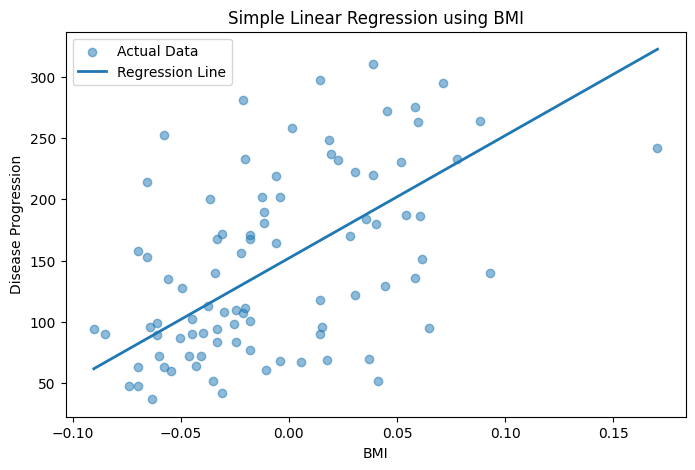


Input Features:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


Target:


,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


Training Samples: 353
Testing Samples : 89

First 10 Predictions:
[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858]

Multiple Linear Regression Evaluation
Mean Squared Error: 2900.1936
R² Score: 0.4526

Model Comparison:


,Model,MSE,R² Score
0,Simple Linear Regression,4061.825928,0.233350
1,Multiple Linear Regression,2900.193628,0.452603



Interpretation:
Multiple Linear Regression performs better than Simple Linear Regression because it uses all available input features instead of only BMI. It has a lower MSE and a higher R² score.


In [ ]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# ============================================================
# LOAD THE DIABETES DATASET
# ============================================================

data = load_diabetes(as_frame=True)

df = data.frame

print("Dataset Shape:", df.shape)

display(df.head())


# ============================================================
# EXAMINE THE DATASET
# ============================================================

print("Feature Names:")
print(data.feature_names)

print("\nTarget Variable:")
print("Disease progression")

print("\nDataset Information:")
df.info()


# ============================================================
# SIMPLE LINEAR REGRESSION
# Using BMI as the independent variable
# ============================================================

# Input feature
X = df[["bmi"]]

# Target variable
y = df["target"]

print("\nInput Feature:")
display(X.head())

print("Target Variable:")
display(y.head())


# ============================================================
# SPLIT THE DATASET
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))


# ============================================================
# CREATE AND TRAIN SIMPLE LINEAR REGRESSION MODEL
# ============================================================

model = LinearRegression()

model.fit(X_train, y_train)


# ============================================================
# DISPLAY LEARNED EQUATION
# ============================================================

print("\nSimple Linear Regression Model")

print("Intercept:", round(model.intercept_, 4))
print("Slope    :", round(model.coef_[0], 4))

print(
    f"\nDisease Progression = "
    f"{model.intercept_:.4f} + "
    f"({model.coef_[0]:.4f} × BMI)"
)


# ============================================================
# MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

print("\nFirst 10 Predictions:")
print(y_pred[:10])


# ============================================================
# EVALUATE SIMPLE LINEAR REGRESSION
# ============================================================

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nSimple Linear Regression Evaluation")

print("Mean Squared Error:", round(mse, 4))
print("R² Score:", round(r2, 4))


# ============================================================
# VISUALIZE SIMPLE LINEAR REGRESSION
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    X_test,
    y_test,
    alpha=0.5,
    label="Actual Data"
)

# Sort BMI values for a proper regression line
X_sorted = X_test.sort_values("bmi")

plt.plot(
    X_sorted,
    model.predict(X_sorted),
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Simple Linear Regression using BMI")
plt.legend()

plt.show()


# ============================================================
# MULTIPLE LINEAR REGRESSION
# Using all input features
# ============================================================

# Input features
X = df.drop(columns=["target"])

# Target
y = df["target"]

print("\nInput Features:")
display(X.head())

print("Target:")
display(y.head())


# ============================================================
# SPLIT DATA
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))


# ============================================================
# CREATE AND TRAIN MULTIPLE LINEAR REGRESSION MODEL
# ============================================================

multiple_model = LinearRegression()

multiple_model.fit(X_train, y_train)


# ============================================================
# MAKE PREDICTIONS
# ============================================================

y_pred_multiple = multiple_model.predict(X_test)

print("\nFirst 10 Predictions:")
print(y_pred_multiple[:10])


# ============================================================
# EVALUATE MULTIPLE LINEAR REGRESSION
# ============================================================

mse_multiple = mean_squared_error(
    y_test,
    y_pred_multiple
)

r2_multiple = r2_score(
    y_test,
    y_pred_multiple
)

print("\nMultiple Linear Regression Evaluation")

print("Mean Squared Error:", round(mse_multiple, 4))
print("R² Score:", round(r2_multiple, 4))


# ============================================================
# COMPARE BOTH MODELS
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MSE": [
        mse,
        mse_multiple
    ],
    "R² Score": [
        r2,
        r2_multiple
    ]
})

print("\nModel Comparison:")

display(comparison)


# ============================================================
# INTERPRETATION
# ============================================================

print("\nInterpretation:")

print(
    "Multiple Linear Regression performs better than "
    "Simple Linear Regression because it uses all available "
    "input features instead of only BMI. It has a lower MSE "
    "and a higher R² score."
)